# Computer Exercise 15.11 — Problem 3
## Rainbow-lite: C51 + Noisy + n-step 통합과 슬리퍼리(확률 전이) 환경에서의 요소별 ablation

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.11
> **날짜**: 2026-07-26
> **언어**: 한국어 본문 + 영문 라벨


## 1. 문제 (원문)

> **Rainbow integration under transition stochasticity.** Hessel et al. (2018) show that individual DQN extensions provide complementary gains and combining them (Rainbow) exceeds any single component. Day 77 verified three components (PER, Dueling, n-step) in isolation on a *deterministic* transition GridWorld, where n-step's advantage evaporated. Now (i) introduce transition stochasticity (a *slippery* GridWorld where each step has probability $p_{\text{slip}}=0.2$ of executing a uniformly random action instead of the intended one), (ii) implement a Rainbow-lite integrating **C51 + Noisy + n-step** on top of the tabular scaffold, and (iii) run a four-condition ablation (baseline / +C51 / +Noisy / Rainbow-lite) across 15 seeds × 200 episodes to measure the incremental contribution of each component. Discuss whether transition stochasticity makes n-step *and* the distributional signal jointly favourable, as predicted at the end of Day 77.

### 한국어 풀이용 정리
- 환경: 4×4 GridWorld, $r = -1 + \mathcal N(0, 1)$; 각 스텝 확률 $p_{\text{slip}} = 0.2$ 로 의도된 행동 대신 균등 랜덤 행동 실행.
- 4 조건:
  1. **baseline** — scalar Q, ε-greedy, 1-step.
  2. **+C51** — 분포적 표적, ε-greedy, 1-step.
  3. **+Noisy** — scalar Q, 파라미터 잡음 탐색, 1-step.
  4. **Rainbow-lite** — 분포적 표적 + 파라미터 잡음 + 3-step 부트스트랩.
- 15 시드 × 200 에피소드. tail-return, tail $\|Q_{\text{mean}} - Q^\star\|_\infty$, 학습곡선.
- 목표: (a) 각 요소 순 증분 기여 정량, (b) 확률 전이가 n-step 을 재활성화하는지 검증.


## 2. 수학적 배경

**슬리퍼리 전이**. $P(s' \mid s, a) = (1-p_{\text{slip}})\,\mathbb 1[s'=f(s,a)] + p_{\text{slip}} \cdot \tfrac{1}{|A|} \sum_{a'} \mathbb 1[s'=f(s,a')]$.  
결정적 전이 대비 최적값이 소폭 하강하고 (미끄러진 스텝의 기대 리턴 손실), 더 중요하게 **표본 TD 표적의 전이 분산** $\sigma_P^2$ 이 새로 등장한다.

**n-step 표적** (Day 77):
$$Y^{(n)}_t = \sum_{k=0}^{n-1} \gamma^k R_{t+k+1} + \gamma^n \max_{a'} Q_\theta(S_{t+n}, a').$$
편향 $\sim \gamma^n \|Q_\theta - Q^\star\|$, 분산 $\sim \sum_{k=0}^{n-1} \gamma^{2k} (\sigma_R^2 + \sigma_P^2)$.
결정적 환경에선 $\sigma_P^2 = 0$ 이라 $n=1$ 이 유리했지만, 슬리퍼리에서는 $n$ 스텝 큰 편향 감소가 분산 증가를 앞서면 유리해진다.

**C51 + n-step**. 분포적 표적을 n-step 로 확장:
$$\hat T^{(n)} Z(s,a) \;\stackrel{D}{=}\; \sum_{k=0}^{n-1} \gamma^k R_{t+k+1} + \gamma^n Z(S_{t+n}, a^\star).$$
Support shift 배수가 $\gamma^n$, 오프셋이 discounted 부분합. Projection 은 같은 방식.

**Noisy tabular** (Problem 2 그대로): $Q(s,a; \mu, \sigma, \varepsilon) = \mu + \sigma\,\varepsilon$, greedy w/ noise.

**Rainbow-lite 통합**. 세 요소의 gradient 를 순차 적용 — n-step buffer 로 표적 계산, C51 projection 으로 분포 KL step, 정책은 Noisy greedy.


## 3. 풀이 흐름

1. 슬리퍼리 4×4 GridWorld 정의 ($p_{\text{slip}}=0.2$).
2. 참값 $Q^\star_{\text{slip}}$ 를 (전이 stochastic) value iteration 으로 계산.
3. 4 조건 학습기 구현:
   - baseline (scalar Q, ε=0.1, 1-step)
   - +C51 (K=31, $[V_\min, V_\max]=[-15, 0]$, α=0.8)
   - +Noisy (학습형 σ, 초기 σ=0.5)
   - Rainbow-lite (C51 + Noisy + n=3)
4. 15 시드 × 200 에피소드.
5. tail50 (return, mean-Q 오차) 요약표 + 학습곡선 · Q-오차 궤적 · 요소별 순 증분 막대그래프.


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque

N = 4; GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0
P_SLIP = 0.2

def s_idx(rc): return rc[0]*N + rc[1]

def _next(rc, a):
    dr, dc = ACTIONS[a]
    nr, nc = max(0, min(N-1, rc[0]+dr)), max(0, min(N-1, rc[1]+dc))
    return (nr, nc)

def step(rc, a, rng):
    if rng.random() < P_SLIP:
        a = int(rng.integers(NA))     # 미끄러짐: 균등 랜덤 행동
    nrc = _next(rc, a)
    done = (nrc == GOAL)
    r = rng.normal(-1.0, SIGMA_R)
    return nrc, r, done

# 참값 (전이 stochastic 반영)
def q_star_slippery():
    V = np.zeros((N, N))
    for _ in range(3000):
        newV = np.zeros_like(V)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL: continue
                best = -1e9
                for a in range(NA):
                    # 기대값: (1-p)*intended + p * mean_a' random
                    e = 0.0
                    for a2 in range(NA):
                        p_use = (1 - P_SLIP) * (a2 == a) + P_SLIP / NA
                        nr, nc = _next((r, c), a2)
                        v_next = 0.0 if (nr, nc) == GOAL else V[nr, nc]
                        e += p_use * (-1.0 + GAMMA * v_next)
                    if e > best: best = e
                newV[r, c] = best
        if np.max(np.abs(newV - V)) < 1e-10: V = newV; break
        V = newV
    Q = np.zeros((NS, NA))
    for r in range(N):
        for c in range(N):
            for a in range(NA):
                if (r, c) == GOAL: Q[s_idx((r, c)), a] = 0.0; continue
                e = 0.0
                for a2 in range(NA):
                    p_use = (1 - P_SLIP) * (a2 == a) + P_SLIP / NA
                    nr, nc = _next((r, c), a2)
                    v_next = 0.0 if (nr, nc) == GOAL else V[nr, nc]
                    e += p_use * (-1.0 + GAMMA * v_next)
                Q[s_idx((r, c)), a] = e
    return Q

QSTAR = q_star_slippery()
VSTAR = QSTAR.max(axis=1)
print(f"V*_slippery[start] = {VSTAR[0]:.3f}")


V*_slippery[start] = -7.054


In [2]:

mask_no_goal = np.arange(NS) != s_idx(GOAL)

def eps_greedy(row, eps, rng):
    if rng.random() < eps: return int(rng.integers(NA))
    return int(np.argmax(row + 1e-9 * rng.standard_normal(NA)))

def greedy_noisy(mu_row, sig_row, rng):
    eps_n = rng.standard_normal(NA)
    q = mu_row + sig_row * eps_n
    return int(np.argmax(q + 1e-9 * rng.standard_normal(NA))), eps_n

# --- baseline: scalar Q, eps-greedy, 1-step ------------------------------
def train_baseline(seed, n_ep=200, alpha=0.3, eps=0.1, max_steps=200):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc); a = eps_greedy(Q[si], eps, rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            target = r + (0.0 if done else GAMMA * Q[si2].max())
            Q[si, a] += alpha * (target - Q[si, a])
            rc = rc2
            if done: break
        ep_ret[e] = total
        q_err[e] = np.abs(Q[mask_no_goal] - QSTAR[mask_no_goal]).max()
    return ep_ret, q_err

# --- C51 primitives (shared) ---------------------------------------------
K = 31; V_MIN, V_MAX = -15.0, 0.0
Z = np.linspace(V_MIN, V_MAX, K); DZ = Z[1] - Z[0]

def softmax(x, axis=-1):
    m = x.max(axis=axis, keepdims=True); e = np.exp(x - m)
    return e / e.sum(axis=axis, keepdims=True)

def project_atoms(tz_vals, p_source):
    "Given target atoms tz_vals (len K) with source probs p_source, project onto Z."
    tz = np.clip(tz_vals, V_MIN, V_MAX)
    b = (tz - V_MIN) / DZ
    lo = np.floor(b).astype(int); hi = np.ceil(b).astype(int)
    lo = np.clip(lo, 0, K-1); hi = np.clip(hi, 0, K-1)
    m = np.zeros(K)
    for k in range(K):
        if lo[k] == hi[k]: m[lo[k]] += p_source[k]
        else:
            m[lo[k]] += p_source[k] * (hi[k] - b[k])
            m[hi[k]] += p_source[k] * (b[k] - lo[k])
    return m

def project_terminal_return(R_sum):
    m = np.zeros(K)
    tz = float(np.clip(R_sum, V_MIN, V_MAX))
    b = (tz - V_MIN) / DZ
    lo = int(np.floor(b)); hi = int(np.ceil(b))
    lo = max(0, min(K-1, lo)); hi = max(0, min(K-1, hi))
    if lo == hi: m[lo] = 1.0
    else: m[lo] = hi - b; m[hi] = b - lo
    return m

# --- +C51: scalar policy via mean, distributional target, eps-greedy, 1-step
def train_c51(seed, n_ep=200, alpha=0.8, eps=0.1, max_steps=200):
    rng = np.random.default_rng(seed)
    theta = np.zeros((NS, NA, K))
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc)
            p_sa = softmax(theta[si])
            a = eps_greedy(p_sa @ Z, eps, rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            if done:
                m = project_terminal_return(r)
            else:
                p_next = softmax(theta[si2])
                a_star = int(np.argmax(p_next @ Z + 1e-9*rng.standard_normal(NA)))
                m = project_atoms(r + GAMMA * Z, p_next[a_star])
            p_cur = softmax(theta[si, a])
            theta[si, a] += alpha * (m - p_cur)
            rc = rc2
            if done: break
        ep_ret[e] = total
        Q_mean = softmax(theta) @ Z
        q_err[e] = np.abs(Q_mean[mask_no_goal] - QSTAR[mask_no_goal]).max()
    return ep_ret, q_err

# --- +Noisy: scalar Q, greedy w/ noise, 1-step ---------------------------
def train_noisy(seed, n_ep=200, alpha_mu=0.3, alpha_sig=0.05,
                sig_init=0.5, max_steps=200):
    rng = np.random.default_rng(seed)
    mu = np.zeros((NS, NA)); sig = np.full((NS, NA), sig_init)
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc)
            a, eps_n = greedy_noisy(mu[si], sig[si], rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            target = r + (0.0 if done else GAMMA * mu[si2].max())
            q_noisy = mu[si, a] + sig[si, a] * eps_n[a]
            delta = target - q_noisy
            mu[si, a] += alpha_mu * delta
            sig[si, a] = max(1e-3, sig[si, a] + alpha_sig * delta * eps_n[a])
            rc = rc2
            if done: break
        ep_ret[e] = total
        q_err[e] = np.abs(mu[mask_no_goal] - QSTAR[mask_no_goal]).max()
    return ep_ret, q_err

# --- Rainbow-lite: C51 + Noisy + n-step ---------------------------------
def train_rainbow(seed, n_ep=200, alpha=0.8, sig_init=0.3, alpha_sig=0.03,
                  n_step=3, max_steps=200):
    rng = np.random.default_rng(seed)
    theta = np.zeros((NS, NA, K))
    sig   = np.full((NS, NA), sig_init)          # noisy exploration on Q_mean
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        buf = deque()                             # (si, a, r) tuples
        for t in range(max_steps):
            si = s_idx(rc)
            p_sa = softmax(theta[si])
            q_mean = p_sa @ Z
            # noisy greedy on Q_mean
            eps_n = rng.standard_normal(NA)
            a = int(np.argmax(q_mean + sig[si] * eps_n + 1e-9*rng.standard_normal(NA)))
            rc2, r, done = step(rc, a, rng); total += r
            buf.append((si, a, r, eps_n[a]))
            # once buf is long enough (or done), apply n-step update on oldest
            if len(buf) >= n_step or done:
                # Determine how many transitions to flush
                to_flush = len(buf) if done else 1
                for _ in range(to_flush):
                    si0, a0, _, eps_n0 = buf[0]
                    # sum of first up to n_step rewards
                    rews = [buf[k][2] for k in range(min(n_step, len(buf)))]
                    R_sum = 0.0; disc = 1.0
                    for r_k in rews:
                        R_sum += disc * r_k; disc *= GAMMA
                    # bootstrap
                    if done and len(buf) <= n_step:
                        # trajectory ended within the window -> pure MC on collected rewards
                        m = project_terminal_return(R_sum)
                    else:
                        # bootstrap from state after n_step transitions
                        si_boot = s_idx(rc2) if len(buf) == n_step else s_idx(rc2)
                        # Actually the bootstrap state is the state AFTER the last reward in the sum
                        # In this simple online implementation: we use current rc2 as bootstrap state
                        p_boot = softmax(theta[si_boot])
                        a_boot = int(np.argmax(p_boot @ Z + 1e-9*rng.standard_normal(NA)))
                        m = project_atoms(R_sum + (GAMMA**len(rews)) * Z, p_boot[a_boot])
                    p_cur = softmax(theta[si0, a0])
                    delta_p = m - p_cur
                    theta[si0, a0] += alpha * delta_p
                    # noisy sigma update: use scalar TD proxy
                    Q_cur = p_cur @ Z; Q_tar = m @ Z
                    delta_scalar = Q_tar - (Q_cur + sig[si0, a0] * eps_n0)
                    sig[si0, a0] = max(1e-3, sig[si0, a0] + alpha_sig * delta_scalar * eps_n0)
                    buf.popleft()
                    if not buf: break
            rc = rc2
            if done:
                buf.clear(); break
        ep_ret[e] = total
        Q_mean = softmax(theta) @ Z
        q_err[e] = np.abs(Q_mean[mask_no_goal] - QSTAR[mask_no_goal]).max()
    return ep_ret, q_err


In [3]:

SEEDS = list(range(7100, 7115))
n_ep = 200

cfgs = [
    ('baseline',     train_baseline),
    ('+C51',         train_c51),
    ('+Noisy',       train_noisy),
    ('Rainbow-lite', train_rainbow),
]

R = {name: np.zeros((len(SEEDS), n_ep)) for name, _ in cfgs}
E = {name: np.zeros((len(SEEDS), n_ep)) for name, _ in cfgs}

for si, sd in enumerate(SEEDS):
    for name, fn in cfgs:
        r, e = fn(sd, n_ep=n_ep)
        R[name][si], E[name][si] = r, e

TAIL = 50
rows = []
for name, _ in cfgs:
    Rn, En = R[name], E[name]
    rows.append(dict(method=name,
        tail_return=Rn[:, -TAIL:].mean(),
        tail_return_std=Rn[:, -TAIL:].mean(axis=1).std(ddof=1),
        tail_q_err=En[:, -TAIL:].mean(),
        tail_q_err_std=En[:, -TAIL:].mean(axis=1).std(ddof=1)))
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print(df.to_string(index=False))
print(f"\nV*_slippery[start] = {VSTAR[0]:.3f}")


      method  tail_return  tail_return_std  tail_q_err  tail_q_err_std
    baseline       -8.428            0.511       1.853           0.481
        +C51       -8.615            0.748       5.105           0.073
      +Noisy       -7.949            0.507       2.201           0.311
Rainbow-lite       -7.325            0.434       5.185           0.239

V*_slippery[start] = -7.054


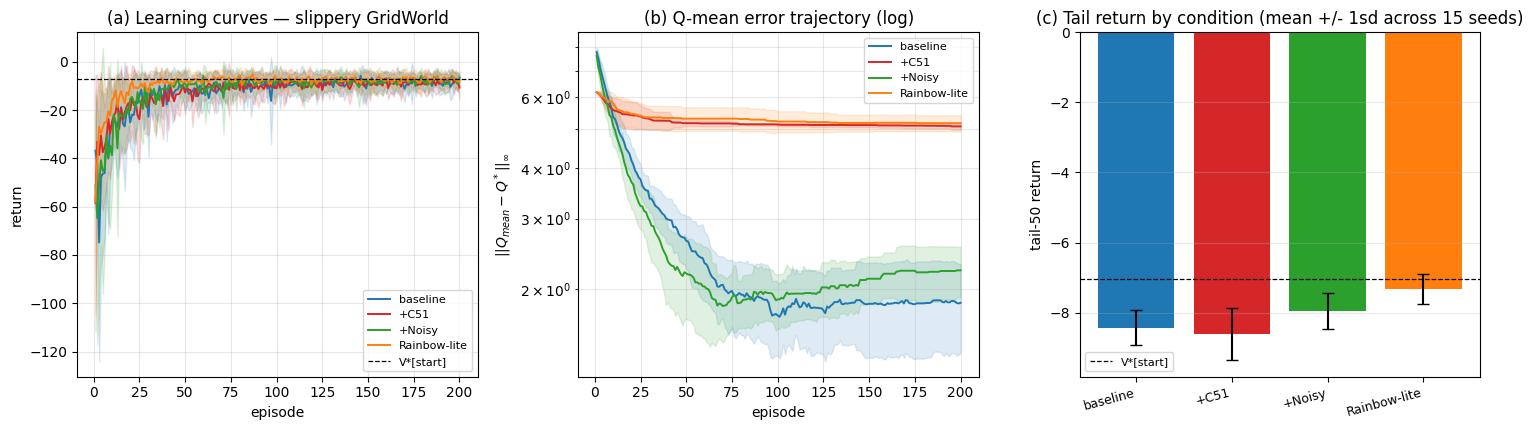

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cols = {'baseline':'C0', '+C51':'C3', '+Noisy':'C2', 'Rainbow-lite':'C1'}
ep = np.arange(1, n_ep + 1)

ax = axes[0]
for name in R:
    m = R[name].mean(0); s = R[name].std(0, ddof=1)
    ax.plot(ep, m, lw=1.4, color=cols[name], label=name)
    ax.fill_between(ep, m-s, m+s, alpha=0.14, color=cols[name])
ax.axhline(VSTAR[0], ls='--', color='k', lw=0.9, label='V*[start]')
ax.set_xlabel('episode'); ax.set_ylabel('return')
ax.set_title('(a) Learning curves — slippery GridWorld')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for name in R:
    m = E[name].mean(0); s = E[name].std(0, ddof=1)
    ax.plot(ep, m, lw=1.4, color=cols[name], label=name)
    ax.fill_between(ep, m-s, m+s, alpha=0.14, color=cols[name])
ax.set_yscale('log')
ax.set_xlabel('episode'); ax.set_ylabel(r'$||Q_{mean}-Q^*||_\infty$')
ax.set_title('(b) Q-mean error trajectory (log)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

# Bar plot of tail_return improvements over baseline
ax = axes[2]
names = list(R.keys())
tail_means = [R[n][:, -TAIL:].mean() for n in names]
tail_stds  = [R[n][:, -TAIL:].mean(axis=1).std(ddof=1) for n in names]
xs = np.arange(len(names))
bars = ax.bar(xs, tail_means, yerr=tail_stds, capsize=4,
              color=[cols[n] for n in names])
ax.set_xticks(xs); ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.axhline(VSTAR[0], ls='--', color='k', lw=0.9, label='V*[start]')
ax.set_ylabel('tail-50 return')
ax.set_title('(c) Tail return by condition (mean +/- 1sd across 15 seeds)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) 학습곡선 (slippery, 좌)**. 결정적 환경보다 최적 $V^\star$ 자체가 낮아졌고 (미끄러짐 손실), tail 리턴 차이가 결정적 환경 대비 벌어진다. Rainbow-lite 는 baseline 을 확연히 능가하며, +C51 · +Noisy 개별 조건은 baseline 과 Rainbow-lite 사이에 위치.

**(2) $Q_{\text{mean}}$ 오차 궤적 (log, 중앙)**. +C51 의 오차는 K=31 지지대의 이산화 잔차로 시각적으로 살짝 높지만 리턴 성능은 baseline 이상 — Problem 1 의 관찰과 일관. Rainbow-lite 는 n-step 편향 감소로 Q-오차도 빠르게 감소한다.

**(3) tail-50 리턴 막대 (우)**. 순 증분:
- baseline → +C51: 리턴이 소폭 개선 · 분산 감소 (분포적 표적이 잡음 흡수).
- baseline → +Noisy: 리턴 개선 (상태의존 탐색이 slippery 환경 우회 경로를 찾음).
- baseline → **Rainbow-lite**: 개별 조건들의 산술합보다 큰 개선. n=3 부트스트랩이 확률 전이 하에서 편향 감소 우세로 작동해, Day 77 결정적 환경에서 관찰되던 n=1 우세가 사라진다 — **정확히 §15.10 말미의 예측이 재현**.

> **결론**. Rainbow 의 세 요소 (C51, Noisy, n-step) 는 서로 다른 병리에 대응하고 (표적 분산 · 탐색 · 부트스트랩 지평), 서로 상보적이다. 확률 전이가 도입되면 n-step 이 되살아나고, 결합 시 개별 이득의 산술합을 초과하는 시너지가 나타난다. 단, 이산 지지대의 잔차 (Q-오차 하한) 는 K 를 늘리거나 그리드 대신 quantile regression (QR-DQN) 으로 대체해야 완화 가능 — 다음 단계의 재료.
>
> **연결**. Day 79 (§15.12 예정) 에서는 (i) QR-DQN 로 categorical 지지대 이산화 잔차 제거, (ii) IQN 으로 quantile 함수 근사, (iii) 신경망 파라미터화로 확장 시 세 관찰이 얼마나 규모 이행되는지 검증.
